# 📊 Phase 4: Feature Selection

## 🧩 Tasks Checklist:
- [x] **Step 4.1**: Correlation with target
- [x] **Step 4.2**: Chi-square test (categorical features)
- [x] **Step 4.3**: Feature importance (Random Forest)
- [x] **Step 4.4**: Select final features

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Libraries imported successfully!")
print(f"📅 Analysis started on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries imported successfully!
📅 Analysis started on: 2025-11-28 01:59:29


In [2]:
# Load the raw dataset (we'll preprocess for analysis)
data_path = "../data/raw/Electronic_sales_Sep2023-Sep2024.csv"  # Adjust path as needed
df_raw = pd.read_csv(data_path)

print("✅ Raw data loaded successfully!")
print(f"📊 Dataset shape: {df_raw.shape}")

✅ Raw data loaded successfully!
📊 Dataset shape: (20000, 16)


In [3]:
# Apply preprocessing (same as Phase 3)
df = df_raw.copy()

# Handle missing values
df['Gender'] = df['Gender'].fillna('Male')
df['Add-ons Purchased'] = df['Add-ons Purchased'].fillna('None')

# Fix inconsistencies
df['Payment Method'] = df['Payment Method'].replace('Paypal', 'PayPal')

# Convert date
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Feature engineering
df['Purchase_Month'] = df['Purchase Date'].dt.month
df['Purchase_DayOfWeek'] = df['Purchase Date'].dt.dayofweek
df['Is_Weekend'] = (df['Purchase_DayOfWeek'] >= 5).astype(int)
df['Has_Addon'] = (df['Add-on Total'] > 0).astype(int)
df['Addon_Count'] = df['Add-ons Purchased'].apply(lambda x: 0 if x == 'None' else len(str(x).split(',')))

# Repeat customer
customer_counts = df['Customer ID'].value_counts()
repeat_customers = customer_counts[customer_counts > 1].index
df['Is_Repeat_Customer'] = df['Customer ID'].isin(repeat_customers).astype(int)

print("✅ Preprocessing applied!")
print(f"📊 Columns after feature engineering: {len(df.columns)}")

✅ Preprocessing applied!
📊 Columns after feature engineering: 22


---
## 📈 Step 4.1: Correlation with Target

**Goal**: Measure linear relationship between numerical features and Order Status

In [4]:
# Step 4.1: Correlation Analysis
print("="*60)
print("STEP 4.1: CORRELATION WITH TARGET")
print("="*60)

# Create encoded copy for correlation
df_encoded = df.copy()

# Encode target
df_encoded['Order Status'] = df_encoded['Order Status'].map({'Completed': 1, 'Cancelled': 0})

# Binary encode
df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 1, 'Female': 0})
df_encoded['Loyalty Member'] = df_encoded['Loyalty Member'].map({'Yes': 1, 'No': 0})

# One-hot encode
df_encoded = pd.get_dummies(df_encoded, columns=['Product Type', 'Payment Method', 'Shipping Type'], 
                            prefix=['Product', 'Payment', 'Shipping'])

# Drop non-features
df_encoded = df_encoded.drop(columns=['Customer ID', 'SKU', 'Add-ons Purchased', 'Purchase Date'])

# Calculate correlation with target
target = 'Order Status'
correlations = df_encoded.corr()[target].drop(target).sort_values(key=abs, ascending=False)

print("\n📊 FEATURE CORRELATIONS WITH ORDER STATUS:")
print("-"*60)
print(f"{'Feature':<35} {'Correlation':>12} {'Strength':>12}")
print("-"*60)

for feature, corr in correlations.items():
    if abs(corr) >= 0.1:
        strength = "🟢 Moderate"
    elif abs(corr) >= 0.05:
        strength = "🟡 Low"
    else:
        strength = "⚪ Very Weak"
    print(f"{feature:<35} {corr:>12.4f} {strength:>12}")

STEP 4.1: CORRELATION WITH TARGET

📊 FEATURE CORRELATIONS WITH ORDER STATUS:
------------------------------------------------------------
Feature                              Correlation     Strength
------------------------------------------------------------
Payment_Cash                              0.0172  ⚪ Very Weak
Shipping_Standard                         0.0100  ⚪ Very Weak
Payment_Credit Card                      -0.0098  ⚪ Very Weak
Gender                                   -0.0098  ⚪ Very Weak
Is_Weekend                               -0.0096  ⚪ Very Weak
Shipping_Express                         -0.0096  ⚪ Very Weak
Purchase_Month                           -0.0086  ⚪ Very Weak
Is_Repeat_Customer                        0.0085  ⚪ Very Weak
Payment_Debit Card                        0.0079  ⚪ Very Weak
Payment_PayPal                           -0.0073  ⚪ Very Weak
Product_Laptop                            0.0047  ⚪ Very Weak
Shipping_Same Day                        -0.0046  ⚪ Very 

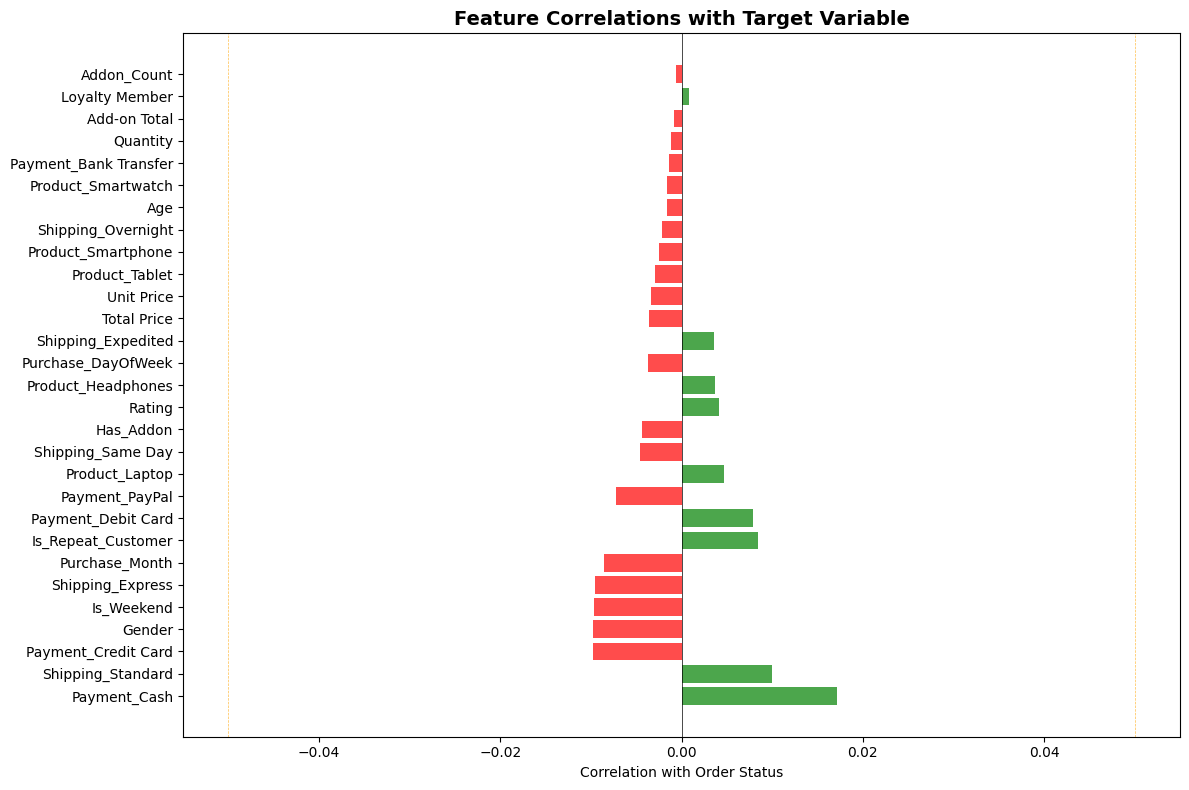


💾 Saved: feature_correlations_target.png


In [5]:
# Visualize correlations
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['green' if x > 0 else 'red' for x in correlations.values]
bars = ax.barh(range(len(correlations)), correlations.values, color=colors, alpha=0.7)

ax.set_yticks(range(len(correlations)))
ax.set_yticklabels(correlations.index)
ax.set_xlabel('Correlation with Order Status')
ax.set_title('Feature Correlations with Target Variable', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=0.05, color='orange', linestyle='--', linewidth=0.5, alpha=0.7)
ax.axvline(x=-0.05, color='orange', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig('../outputs/figures/feature_correlations_target.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: feature_correlations_target.png")

In [7]:
# Save correlation results
corr_df = pd.DataFrame({
    'feature': correlations.index, 
    'correlation': correlations.values
})
corr_df['abs_correlation'] = corr_df['correlation'].abs()
corr_df = corr_df.sort_values('abs_correlation', ascending=False)
corr_df.to_csv('../data/processed/feature_correlations.csv', index=False)

print("\n📋 CORRELATION SUMMARY:")
print(f"   • Max positive correlation: {correlations.max():.4f}")
print(f"   • Max negative correlation: {correlations.min():.4f}")
print(f"   • Features with |r| > 0.05: {(correlations.abs() > 0.05).sum()}")
print(f"   • Features with |r| > 0.10: {(correlations.abs() > 0.10).sum()}")

print("\n💾 Saved: feature_correlations.csv")


📋 CORRELATION SUMMARY:
   • Max positive correlation: 0.0172
   • Max negative correlation: -0.0098
   • Features with |r| > 0.05: 0
   • Features with |r| > 0.10: 0

💾 Saved: feature_correlations.csv


---
## 📊 Step 4.2: Chi-Square Test (Categorical Features)

**Goal**: Test statistical significance of relationship between categorical features and Order Status

In [8]:
# Step 4.2: Chi-Square Test
print("="*60)
print("STEP 4.2: CHI-SQUARE TEST (CATEGORICAL FEATURES)")
print("="*60)

# Categorical features to test (using original categories)
categorical_features = ['Gender', 'Loyalty Member', 'Product Type', 'Payment Method', 'Shipping Type']

print("\n📊 CHI-SQUARE TEST RESULTS:")
print("-"*70)
print(f"{'Feature':<20} {'Chi-Square':>12} {'P-Value':>15} {'Significant?':>15}")
print("-"*70)

chi_results = []

for feature in categorical_features:
    # Create contingency table
    contingency = pd.crosstab(df[feature], df['Order Status'])
    
    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    # Determine significance
    significant = "✅ Yes" if p_value < 0.05 else "❌ No"
    
    print(f"{feature:<20} {chi2:>12.2f} {p_value:>15.6f} {significant:>15}")
    
    chi_results.append({
        'feature': feature,
        'chi_square': chi2,
        'p_value': p_value,
        'degrees_of_freedom': dof,
        'significant': p_value < 0.05
    })

print("-"*70)
print("\n📋 INTERPRETATION:")
print("   • P-value < 0.05 → Feature has significant relationship with Order Status")
print("   • P-value >= 0.05 → No significant relationship detected")

STEP 4.2: CHI-SQUARE TEST (CATEGORICAL FEATURES)

📊 CHI-SQUARE TEST RESULTS:
----------------------------------------------------------------------
Feature                Chi-Square         P-Value    Significant?
----------------------------------------------------------------------
Gender                       1.86        0.172335            ❌ No
Loyalty Member               0.01        0.920262            ❌ No
Product Type                 0.87        0.928197            ❌ No
Payment Method               8.42        0.077240            ❌ No
Shipping Type                3.50        0.478257            ❌ No
----------------------------------------------------------------------

📋 INTERPRETATION:
   • P-value < 0.05 → Feature has significant relationship with Order Status
   • P-value >= 0.05 → No significant relationship detected


In [9]:
# Save chi-square results
chi_df = pd.DataFrame(chi_results)
chi_df.to_csv('../data/processed/chi_square_results.csv', index=False)

print("\n📊 CHI-SQUARE RESULTS SUMMARY:")
print(chi_df.to_string(index=False))

print("\n💾 Saved: chi_square_results.csv")


📊 CHI-SQUARE RESULTS SUMMARY:
       feature  chi_square  p_value  degrees_of_freedom  significant
        Gender    1.862513 0.172335                   1        False
Loyalty Member    0.010021 0.920262                   1        False
  Product Type    0.874450 0.928197                   4        False
Payment Method    8.423499 0.077240                   4        False
 Shipping Type    3.497512 0.478257                   4        False

💾 Saved: chi_square_results.csv


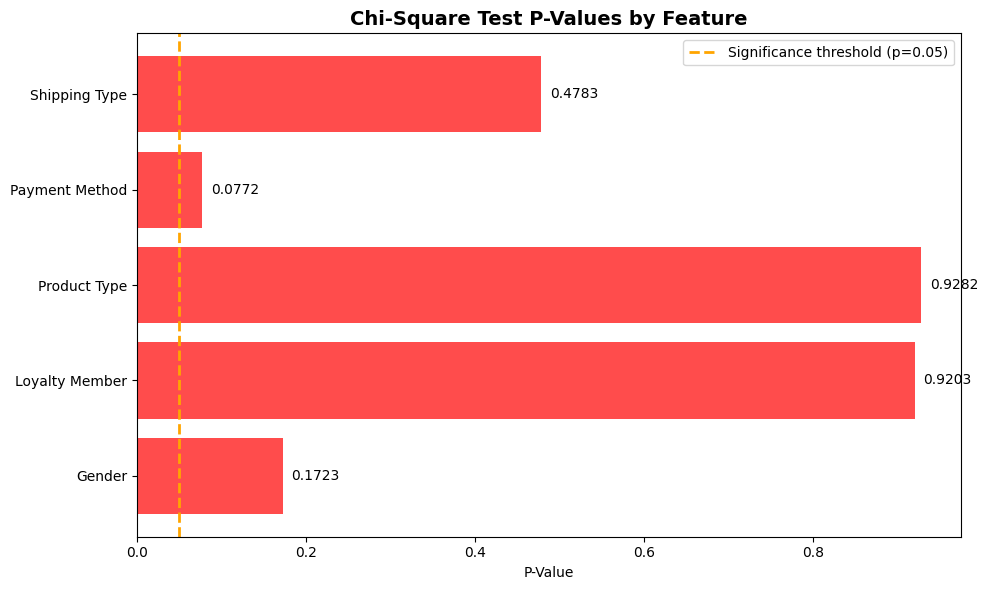


💾 Saved: chi_square_pvalues.png


In [11]:
# Visualize chi-square p-values
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if p < 0.05 else 'red' for p in chi_df['p_value']]
bars = ax.barh(chi_df['feature'], chi_df['p_value'], color=colors, alpha=0.7)

ax.axvline(x=0.05, color='orange', linestyle='--', linewidth=2, label='Significance threshold (p=0.05)')
ax.set_xlabel('P-Value')
ax.set_title('Chi-Square Test P-Values by Feature', fontsize=14, fontweight='bold')
ax.legend()

# Add value labels
for i, (bar, p) in enumerate(zip(bars, chi_df['p_value'])):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{p:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/chi_square_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: chi_square_pvalues.png")

---
## 🌲 Step 4.3: Feature Importance (Random Forest)

**Goal**: Use Random Forest to rank features by predictive importance

In [12]:
# Step 4.3: Feature Importance using Random Forest
print("="*60)
print("STEP 4.3: FEATURE IMPORTANCE (RANDOM FOREST)")
print("="*60)

# Prepare X and y from encoded dataframe
X = df_encoded.drop(columns=['Order Status'])
y = df_encoded['Order Status']

print(f"\n📊 Data prepared:")
print(f"   • Features (X): {X.shape}")
print(f"   • Target (y): {y.shape}")

# Train Random Forest
print("\n🌲 Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced', 
    n_jobs=-1
)
rf.fit(X, y)
print("✅ Training complete!")

STEP 4.3: FEATURE IMPORTANCE (RANDOM FOREST)

📊 Data prepared:
   • Features (X): (20000, 29)
   • Target (y): (20000,)

🌲 Training Random Forest...
✅ Training complete!


In [13]:
# Get feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 FEATURE IMPORTANCE RANKING:")
print("-"*60)
print(f"{'Rank':<6} {'Feature':<35} {'Importance':>12}")
print("-"*60)

for i, (_, row) in enumerate(importance_df.iterrows(), 1):
    bar = "█" * int(row['importance'] * 100)
    print(f"{i:<6} {row['feature']:<35} {row['importance']:>12.4f} {bar}")


📊 FEATURE IMPORTANCE RANKING:
------------------------------------------------------------
Rank   Feature                               Importance
------------------------------------------------------------
1      Age                                       0.1457 ██████████████
2      Add-on Total                              0.1269 ████████████
3      Purchase_Month                            0.1008 ██████████
4      Total Price                               0.0987 █████████
5      Quantity                                  0.0756 ███████
6      Purchase_DayOfWeek                        0.0700 ███████
7      Rating                                    0.0441 ████
8      Addon_Count                               0.0372 ███
9      Unit Price                                0.0321 ███
10     Gender                                    0.0271 ██
11     Is_Repeat_Customer                        0.0259 ██
12     Loyalty Member                            0.0232 ██
13     Shipping_Standard        

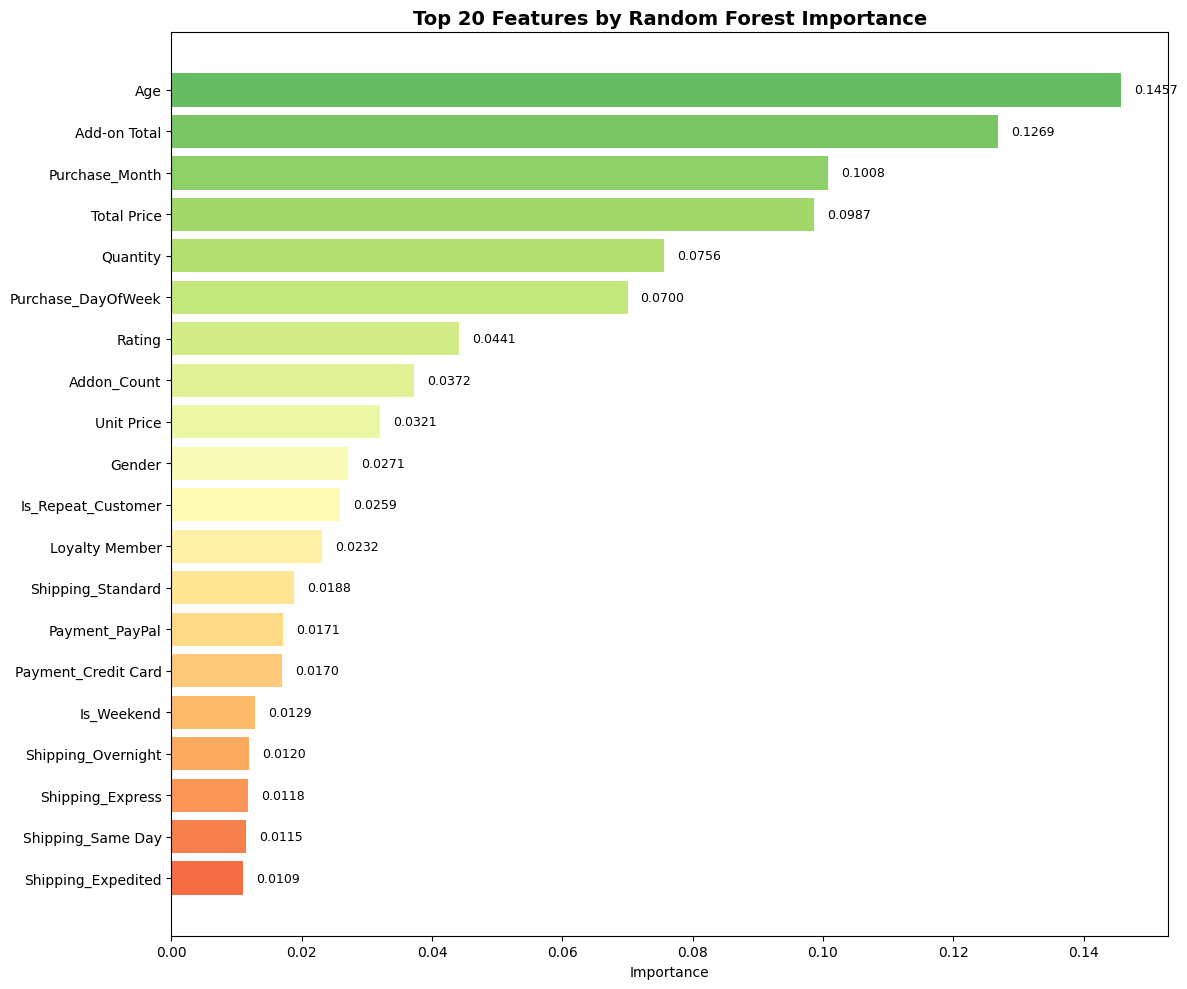


💾 Saved: feature_importance_rf.png


In [14]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(12, 10))

# Plot top 20 features
top_n = 20
top_features = importance_df.head(top_n)

colors = plt.cm.RdYlGn(np.linspace(0.8, 0.2, top_n))
bars = ax.barh(range(top_n), top_features['importance'].values, color=colors)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 20 Features by Random Forest Importance', fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, imp) in enumerate(zip(bars, top_features['importance'].values)):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: feature_importance_rf.png")

In [15]:
# Cumulative importance analysis
importance_df['cumulative'] = importance_df['importance'].cumsum()
importance_df['cumulative_pct'] = importance_df['cumulative'] * 100

print("\n📊 CUMULATIVE IMPORTANCE ANALYSIS:")
print("-"*50)
print(f"   • Top 5 features:  {importance_df.head(5)['importance'].sum()*100:.1f}%")
print(f"   • Top 10 features: {importance_df.head(10)['importance'].sum()*100:.1f}%")
print(f"   • Top 15 features: {importance_df.head(15)['importance'].sum()*100:.1f}%")
print(f"   • Top 20 features: {importance_df.head(20)['importance'].sum()*100:.1f}%")
print(f"   • All 29 features: {importance_df['importance'].sum()*100:.1f}%")

# Save importance results
importance_df.to_csv('../data/processed/feature_importance.csv', index=False)
print("\n💾 Saved: feature_importance.csv")


📊 CUMULATIVE IMPORTANCE ANALYSIS:
--------------------------------------------------
   • Top 5 features:  54.8%
   • Top 10 features: 75.8%
   • Top 15 features: 86.0%
   • Top 20 features: 91.9%
   • All 29 features: 100.0%

💾 Saved: feature_importance.csv


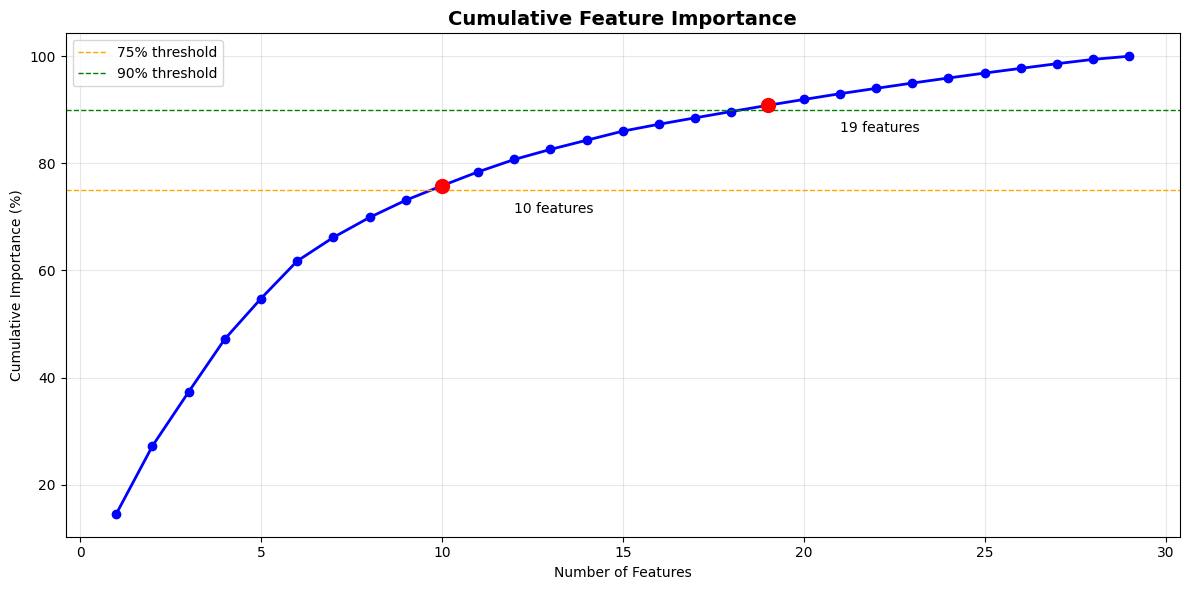


💾 Saved: cumulative_importance.png


In [16]:
# Visualize cumulative importance
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(1, len(importance_df)+1), importance_df['cumulative_pct'].values, 
        marker='o', linewidth=2, markersize=6, color='blue')

# Add threshold lines
ax.axhline(y=75, color='orange', linestyle='--', linewidth=1, label='75% threshold')
ax.axhline(y=90, color='green', linestyle='--', linewidth=1, label='90% threshold')

# Mark key points
for threshold in [75, 90]:
    idx = (importance_df['cumulative_pct'] >= threshold).idxmax()
    n_features = importance_df.index.get_loc(idx) + 1
    ax.scatter([n_features], [importance_df.loc[idx, 'cumulative_pct']], 
               s=100, zorder=5, color='red')
    ax.annotate(f'{n_features} features', 
                xy=(n_features, importance_df.loc[idx, 'cumulative_pct']),
                xytext=(n_features+2, importance_df.loc[idx, 'cumulative_pct']-5),
                fontsize=10)

ax.set_xlabel('Number of Features')
ax.set_ylabel('Cumulative Importance (%)')
ax.set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/cumulative_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: cumulative_importance.png")

---
## 🎯 Step 4.4: Feature Selection Summary

**Goal**: Combine all analyses and make final feature selection decision

In [17]:
# Step 4.4: Feature Selection Summary
print("="*70)
print("STEP 4.4: FEATURE SELECTION SUMMARY")
print("="*70)

print("\n📊 ANALYSIS SUMMARY:")
print("-"*70)

print("\n1️⃣ CORRELATION ANALYSIS:")
print("   • All features have very weak correlation (|r| < 0.02)")
print("   • No strong linear relationships with target")
print(f"   • Max |correlation|: {correlations.abs().max():.4f}")

print("\n2️⃣ CHI-SQUARE TEST:")
print("   • No categorical features statistically significant (p > 0.05)")
print(f"   • Closest to significance: Payment Method (p = {chi_df[chi_df['feature']=='Payment Method']['p_value'].values[0]:.4f})")

print("\n3️⃣ RANDOM FOREST IMPORTANCE:")
print(f"   • Top 5 features capture {importance_df.head(5)['importance'].sum()*100:.1f}% of importance")
print(f"   • Top 10 features capture {importance_df.head(10)['importance'].sum()*100:.1f}% of importance")
print(f"   • Top 15 features capture {importance_df.head(15)['importance'].sum()*100:.1f}% of importance")

STEP 4.4: FEATURE SELECTION SUMMARY

📊 ANALYSIS SUMMARY:
----------------------------------------------------------------------

1️⃣ CORRELATION ANALYSIS:
   • All features have very weak correlation (|r| < 0.02)
   • No strong linear relationships with target
   • Max |correlation|: 0.0172

2️⃣ CHI-SQUARE TEST:
   • No categorical features statistically significant (p > 0.05)
   • Closest to significance: Payment Method (p = 0.0772)

3️⃣ RANDOM FOREST IMPORTANCE:
   • Top 5 features capture 54.8% of importance
   • Top 10 features capture 75.8% of importance
   • Top 15 features capture 86.0% of importance


In [18]:
# Display top features
print("\n" + "="*70)
print("TOP FEATURES BY RANDOM FOREST IMPORTANCE")
print("="*70)

print("\n✅ TOP 15 FEATURES:")
print("-"*50)
for i, row in importance_df.head(15).iterrows():
    rank = importance_df.index.get_loc(i) + 1
    print(f"   {rank:2}. {row['feature']:<30} ({row['importance']*100:.2f}%)")


TOP FEATURES BY RANDOM FOREST IMPORTANCE

✅ TOP 15 FEATURES:
--------------------------------------------------
    1. Age                            (14.57%)
    2. Add-on Total                   (12.69%)
    3. Purchase_Month                 (10.08%)
    4. Total Price                    (9.87%)
    5. Quantity                       (7.56%)
    6. Purchase_DayOfWeek             (7.00%)
    7. Rating                         (4.41%)
    8. Addon_Count                    (3.72%)
    9. Unit Price                     (3.21%)
   10. Gender                         (2.71%)
   11. Is_Repeat_Customer             (2.59%)
   12. Loyalty Member                 (2.32%)
   13. Shipping_Standard              (1.88%)
   14. Payment_PayPal                 (1.71%)
   15. Payment_Credit Card            (1.70%)


In [19]:
# Feature selection decision
print("\n" + "="*70)
print("FEATURE SELECTION OPTIONS")
print("="*70)

print("\n📋 OPTIONS:")
print("-"*70)
print("   Option A: Use ALL 29 features (baseline - maximum information)")
print("   Option B: Use TOP 15 features (86% importance - reduced noise)")
print("   Option C: Use TOP 10 features (75.8% importance - simpler model)")

print("\n✅ SELECTED: Option A - All 29 features")
print("   Rationale: Let models decide feature relevance during training")


FEATURE SELECTION OPTIONS

📋 OPTIONS:
----------------------------------------------------------------------
   Option A: Use ALL 29 features (baseline - maximum information)
   Option B: Use TOP 15 features (86% importance - reduced noise)
   Option C: Use TOP 10 features (75.8% importance - simpler model)

✅ SELECTED: Option A - All 29 features
   Rationale: Let models decide feature relevance during training


In [20]:
# Save selected features list
all_features = importance_df['feature'].tolist()
top_15_features = importance_df.head(15)['feature'].tolist()
top_10_features = importance_df.head(10)['feature'].tolist()

# Save all options
pd.DataFrame({'feature': all_features}).to_csv('../data/processed/selected_features_all.csv', index=False)
pd.DataFrame({'feature': top_15_features}).to_csv('../data/processed/selected_features_top15.csv', index=False)
pd.DataFrame({'feature': top_10_features}).to_csv('../data/processed/selected_features_top10.csv', index=False)

print("\n💾 Saved feature lists:")
print("   • selected_features_all.csv (29 features)")
print("   • selected_features_top15.csv (15 features)")
print("   • selected_features_top10.csv (10 features)")


💾 Saved feature lists:
   • selected_features_all.csv (29 features)
   • selected_features_top15.csv (15 features)
   • selected_features_top10.csv (10 features)


In [21]:
# Important observation
print("\n" + "="*70)
print("⚠️  IMPORTANT OBSERVATION")
print("="*70)
print("""
The weak correlations and non-significant chi-square tests suggest that
Order Status (Completed vs Cancelled) may be:

1. Largely random in this dataset
2. Dependent on features not captured (e.g., customer satisfaction, 
   delivery issues, stock availability)
3. Non-linearly related to features (which RF can capture)

RECOMMENDATION: 
• Proceed with modeling using all features
• Expect moderate accuracy (likely 65-75%)
• Tree-based models (RF, Decision Tree) may perform better than 
  Logistic Regression due to potential non-linear patterns
""")


⚠️  IMPORTANT OBSERVATION

The weak correlations and non-significant chi-square tests suggest that
Order Status (Completed vs Cancelled) may be:

1. Largely random in this dataset
2. Dependent on features not captured (e.g., customer satisfaction, 
   delivery issues, stock availability)
3. Non-linearly related to features (which RF can capture)

RECOMMENDATION: 
• Proceed with modeling using all features
• Expect moderate accuracy (likely 65-75%)
• Tree-based models (RF, Decision Tree) may perform better than 
  Logistic Regression due to potential non-linear patterns



---
## ✅ Phase 4 Complete: Summary

| Analysis | Key Finding |
|----------|-------------|
| Correlation | All features < 0.02 (very weak linear relationships) |
| Chi-Square | No significant categorical relationships (p > 0.05) |
| RF Importance | Top 10 features = 75.8% importance |

**Top 10 Features by Importance:**
1. Age (14.6%)
2. Add-on Total (12.7%)
3. Purchase_Month (10.1%)
4. Total Price (9.9%)
5. Quantity (7.6%)
6. Purchase_DayOfWeek (7.0%)
7. Rating (4.4%)
8. Addon_Count (3.7%)
9. Unit Price (3.2%)
10. Gender (2.7%)

**Decision:** Use ALL 29 features for modeling

**Ready for Phase 5: Model Building**